In [1]:
print('hello world')

hello world


# Summary

**Conclusions:**
This dataset contains house sale prices for King County, including Seattle. It covers homes sold between May 2014 and May 2015, along with variations in price based on the properties’ characteristics.

**Challenges:**
The main challenges were related to missing data, data cleaning, outliers, or feature encoding. I handled these by removing outliers and filling missing values using the mean or most frequent entry.

**Technologies Used:**
- Python (Pandas, NumPy, Matplotlib, Seaborn)  
- Jupyter Notebook  
- Scikit-learn (for regression and model evaluation)

This project helped me practice data wrangling, exploratory data analysis, and basic modeling techniques.


# Import the required libraries

In [12]:
# Surpress warnings:
def warn(*args, **kwargs):
    pass
import warnings
warnings.warn = warn

In [15]:
#!pip install -U scikit-learn

In [19]:
!pip install seaborn

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler,PolynomialFeatures
from sklearn.linear_model import LinearRegression
%matplotlib inline

# Module 1: Importing Data Sets

In [24]:
filepath='https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-DA0101EN-SkillsNetwork/labs/FinalModule_Coursera/data/kc_house_data_NaN.csv'
df = pd.read_csv(filepath, header=None)

In [26]:
df.head()

,0,1,2,3,4,5,6,7,8,9,...,12,13,14,15,16,17,18,19,20,21
0,NaN,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
1,0.0,7129300520,20141013T000000,221900.0,3.0,1.0,1180,5650,1.0,0,...,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
2,1.0,6414100192,20141209T000000,538000.0,3.0,2.25,2570,7242,2.0,0,...,7,2170,400,1951,1991,98125,47.721000000000004,-122.319,1690,7639
3,2.0,5631500400,20150225T000000,180000.0,2.0,1.0,770,10000,1.0,0,...,6,770,0,1933,0,98028,47.7379,-122.23299999999999,2720,8062
4,3.0,2487200875,20141209T000000,604000.0,4.0,3.0,1960,5000,1.0,0,...,7,1050,910,1965,0,98136,47.5208,-122.39299999999999,1360,5000


## Question 1:
### Display the data types of each column using the function dtypes.

In [150]:
df.dtypes

date              object
price             object
bedrooms         float64
bathrooms        float64
sqft_living       object
sqft_lot          object
floors            object
waterfront        object
view              object
condition         object
grade             object
sqft_above        object
sqft_basement     object
yr_built          object
yr_renovated      object
zipcode           object
lat               object
long              object
sqft_living15     object
sqft_loft15       object
dtype: object

### We use the method describe to obtain a statistical summary of the dataframe.

In [37]:
df.describe()

,0
count,21613.00000
mean,10806.00000
std,6239.28002
min,0.00000
25%,5403.00000
50%,10806.00000
75%,16209.00000
max,21612.00000


### Creating headers list

In [56]:
headers = ["Unnamed", "id", "date", "price", "bedrooms", "bathrooms", "sqft_living", "sqft_lot", "floors", "waterfront", "view", "condition", "grade", "sqft_above", "sqft_basement", "yr_built", "yr_renovated", "zipcode", "lat", "long", "sqft_living15", "sqft_loft15"]
headers

['Unnamed',
 'id',
 'date',
 'price',
 'bedrooms',
 'bathrooms',
 'sqft_living',
 'sqft_lot',
 'floors',
 'waterfront',
 'view',
 'condition',
 'grade',
 'sqft_above',
 'sqft_basement',
 'yr_built',
 'yr_renovated',
 'zipcode',
 'lat',
 'long',
 'sqft_living15',
 'sqft_loft15']

In [60]:
df.columns = headers
df.columns

Index(['Unnamed', 'id', 'date', 'price', 'bedrooms', 'bathrooms',
       'sqft_living', 'sqft_lot', 'floors', 'waterfront', 'view', 'condition',
       'grade', 'sqft_above', 'sqft_basement', 'yr_built', 'yr_renovated',
       'zipcode', 'lat', 'long', 'sqft_living15', 'sqft_loft15'],
      dtype='object')

# Data Wrangling
## Question 2: 

In [75]:
#Drop the columns "id" and "Unnamed: 0" from axis 1 using the method drop(), then use the method describe() to obtain a statistical summary of the data. Make sure the inplace parameter is set to True.

In [63]:
df.drop(["id", "Unnamed"], axis=1, inplace=True)

In [65]:
df.describe()

,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_loft15
count,21614,21614,21601,21604,21614,21614,21614,21614,21614,21614,21614,21614,21614,21614,21614,21614,21614,21614,21614,21614
unique,373,4029,13,30,1039,9783,7,3,6,6,13,947,307,117,71,71,5035,753,778,8690
top,20140623T000000,450000.0,3.0,2.5,1300,5000,1.0,0,0,3,7,1300,0,2014,0,98103,47.6846,-122.29,1540,5000
freq,142,172,9824,5380,138,358,10680,21450,19489,14031,8981,212,13126,559,20699,602,17,116,197,427


In [79]:
# We can see we have missing values for the columns bedrooms and bathrooms:

In [81]:
print("number of NaN values for the column bedrooms :", df['bedrooms'].isnull().sum())

number of NaN values for the column bedrooms : 13


In [83]:
print("number of NaN values for the column bathrooms :", df['bathrooms'].isnull().sum())

number of NaN values for the column bathrooms : 10


In [85]:
# We can replace the missing values of the column 'bedrooms' with the mean of the column 'bedrooms' using the method replace(). Don't forget to set the inplace parameter to True

In [95]:
df['bedrooms'].unique()


array(['bedrooms', '3.0', '2.0', '4.0', '5.0', '1.0', '6.0', '7.0', nan,
       '8.0', '9.0', '11.0', '10.0', '33.0'], dtype=object)

In [105]:
df['bedrooms'] = pd.to_numeric(df['bedrooms'], errors='coerce')

In [103]:
mean = df['bedrooms'].mean()
df['bedrooms'].replace(np.nan, mean, inplace=True)

In [107]:
df['bathrooms'].unique()

array(['bathrooms', '1.0', '2.25', '3.0', '2.0', '4.5', '1.5', '2.5',
       '1.75', '2.75', '3.25', '4.0', '3.5', '0.75', '4.75', '5.0',
       '4.25', '3.75', nan, '1.25', '5.25', '6.0', '0.5', '5.5', '6.75',
       '5.75', '8.0', '7.5', '7.75', '6.25', '6.5'], dtype=object)

In [109]:
df['bathrooms'] = pd.to_numeric(df['bathrooms'], errors='coerce')

In [111]:
mean = df['bathrooms'].mean()

In [113]:
df['bathrooms'].replace(np.nan, mean, inplace=True)

In [115]:
print("number of NaN values for the column bedrooms :", df['bedrooms'].isnull().sum())
print("number of NaN values for the column bathrooms :", df['bathrooms'].isnull().sum())

number of NaN values for the column bedrooms : 0
number of NaN values for the column bathrooms : 0


# Exploratory Data Analysis

## Question 3:

In [119]:
# Use the method value_counts to count the number of houses with unique floor values, use the method .to_frame() to convert it to a data frame. 

In [123]:
# Count the number of houses with unique floor values
floors_counts = df['floors'].value_counts()

# Convert to DataFrame
floors_counts_df = floors_counts.to_frame()

# Show the dataframe
print(floors_counts_df)


        count
floors       
1.0     10680
2.0      8241
1.5      1910
3.0       613
2.5       161
3.5         8
floors      1


## Question 4:

In [126]:
#Use the function boxplot in the seaborn library to determine whether houses with a waterfront view or without a waterfront view have more price outliers.

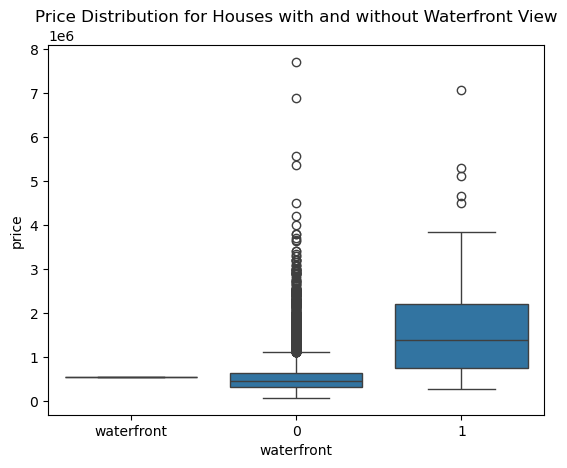

In [220]:
import seaborn as sns
import matplotlib.pyplot as plt

%matplotlib inline

# Create the boxplot comparing the price with the column "waterfront"
sns.boxplot(x='waterfront', y='price', data=df)

# Add a title to the graph
plt.title('Price Distribution for Houses with and without Waterfront View')

# Show the graph
plt.show()


#### We can conclude with this graph that houses without waterfront have more outliers prices.

## Question 5:

In [155]:
# Use the function regplot in the seaborn library to determine if the feature sqft_above is negatively or positively correlated with price.

In [165]:
df['sqft_above'].unique()

array(['sqft_above', '1180', '2170', '770', '1050', '1680', '3890',
       '1715', '1060', '1890', '1860', '860', '1430', '1370', '1810',
       '1980', '1600', '1200', '1250', '2330', '2270', '1070', '2450',
       '1710', '1750', '1400', '790', '2570', '2320', '1190', '1510',
       '1090', '1280', '930', '2360', '890', '2620', '2600', '3595',
       '1570', '920', '3160', '990', '2290', '2165', '1640', '1000',
       '2130', '2830', '2250', '2420', '3250', '1850', '1590', '1260',
       '2519', '1540', '1110', '1770', '2720', '2240', '3070', '2380',
       '2390', '880', '1040', '910', '3450', '2350', '1900', '1010',
       '960', '2660', '1610', '765', '3520', '1290', '1960', '1160',
       '1210', '1270', '1440', '2190', '2920', '1460', '1170', '1240',
       '3140', '2030', '2310', '700', '1080', '2520', '2780', '1560',
       '1450', '1720', '2910', '1620', '1360', '2070', '2460', '1390',
       '2140', '1320', '1340', '1550', '940', '1380', '3670', '2370',
       '1130', '980',

In [169]:
# dtype = object. It means that we have non-numeric values on this column. 
# First of all, we need to convert these values to numeric:

In [171]:
df['sqft_above'] = pd.to_numeric(df['sqft_above'], errors='coerce')

In [173]:
# After that, we need to replace the NaN with the mean:

In [190]:
mean = df['sqft_above'].mean()
df['sqft_above'].replace(np.nan, mean, inplace=True)

In [194]:
# Now we need to verify if both have numeric values:

In [196]:
print(df['sqft_above'].dtype)
print(df['price'].dtype)

float64
object


In [198]:
# Price has object type, so we need to convert the column "price" in numeric values:

In [200]:
df['price'] = pd.to_numeric(df['price'], errors='coerce')

In [202]:
# Replace the NaN with the mean:

In [204]:
mean = df['price'].mean()

In [206]:
df['price'].replace(np.nan, mean, inplace=True)

In [208]:
print(df['sqft_above'].dtype)
print(df['price'].dtype)

float64
float64


In [212]:
# Verify if we have missing values:

In [214]:
print("number of NaN values for the column sqft_above :", df['sqft_above'].isnull().sum())
print("number of NaN values for the column price :", df['price'].isnull().sum())

number of NaN values for the column sqft_above : 0
number of NaN values for the column price : 0


In [216]:
# Now we can make the regplot graph:

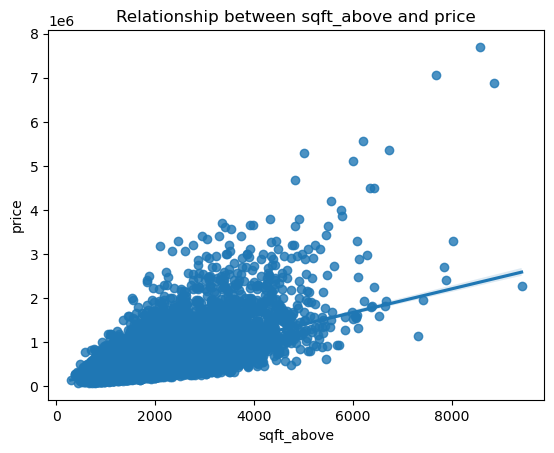

In [218]:
sns.regplot(x='sqft_above', y='price', data=df)
plt.title("Relationship between sqft_above and price")
plt.show()

#### We can conclude with this graph that the feature sqft_above is positively correlated with price.

In [224]:
# We can use the Pandas method corr() to find the feature other than price that is most correlated with price.

In [226]:
df_numeric = df.select_dtypes(include=[np.number])
df_numeric.corr()['price'].sort_values()

bedrooms      0.308797
bathrooms     0.525738
sqft_above    0.605567
price         1.000000
Name: price, dtype: float64

#### The feature that is most correlated with price in this dataset is sqft_above with a correlation of 0.61. This suggests that the size of the house (in terms of square footage above ground) has a significant impact on the price.